# Assignment 5 - Real Sentinel-2 imagery and NDVI

This notebook presents the real Sentinel-2 Level-2A scene selected by the Assignment 5 pipeline for the 25 Story County fields. It reads the committed scene metadata, field summaries, and figures generated from public Element 84 Earth Search assets; no synthetic imagery or NDVI values are used.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
for parent in (ROOT, *ROOT.parents):
    if (parent / "data/processed/assignment-05/scene.json").is_file():
        ROOT = parent
        break

scene = json.loads((ROOT / "data/processed/assignment-05/scene.json").read_text())
fields = pd.read_csv(ROOT / "data/processed/assignment-05/field_ndvi.csv")
assert len(fields) == 25 and fields["field_id"].nunique() == 25
assert scene["study_area_valid_scl_fraction"] >= 0.70

print(f"scene: {scene['selected_scene_id']}")
print(f"acquired: {scene['selected_scene_datetime']}")
print(f"study-area valid SCL fraction: {scene['study_area_valid_scl_fraction']:.3f}")
print(f"rejected candidates before selection: {len(scene['rejected_candidates'])}")

scene: S2B_15TVG_20230620_0_L2A
acquired: 2023-06-20T17:12:11.504000Z
study-area valid SCL fraction: 1.000
rejected candidates before selection: 0


## Real red-band image

The image below is the selected scene's real 10 m red surface-reflectance window. Cyan outlines mark the 25 selected fields.

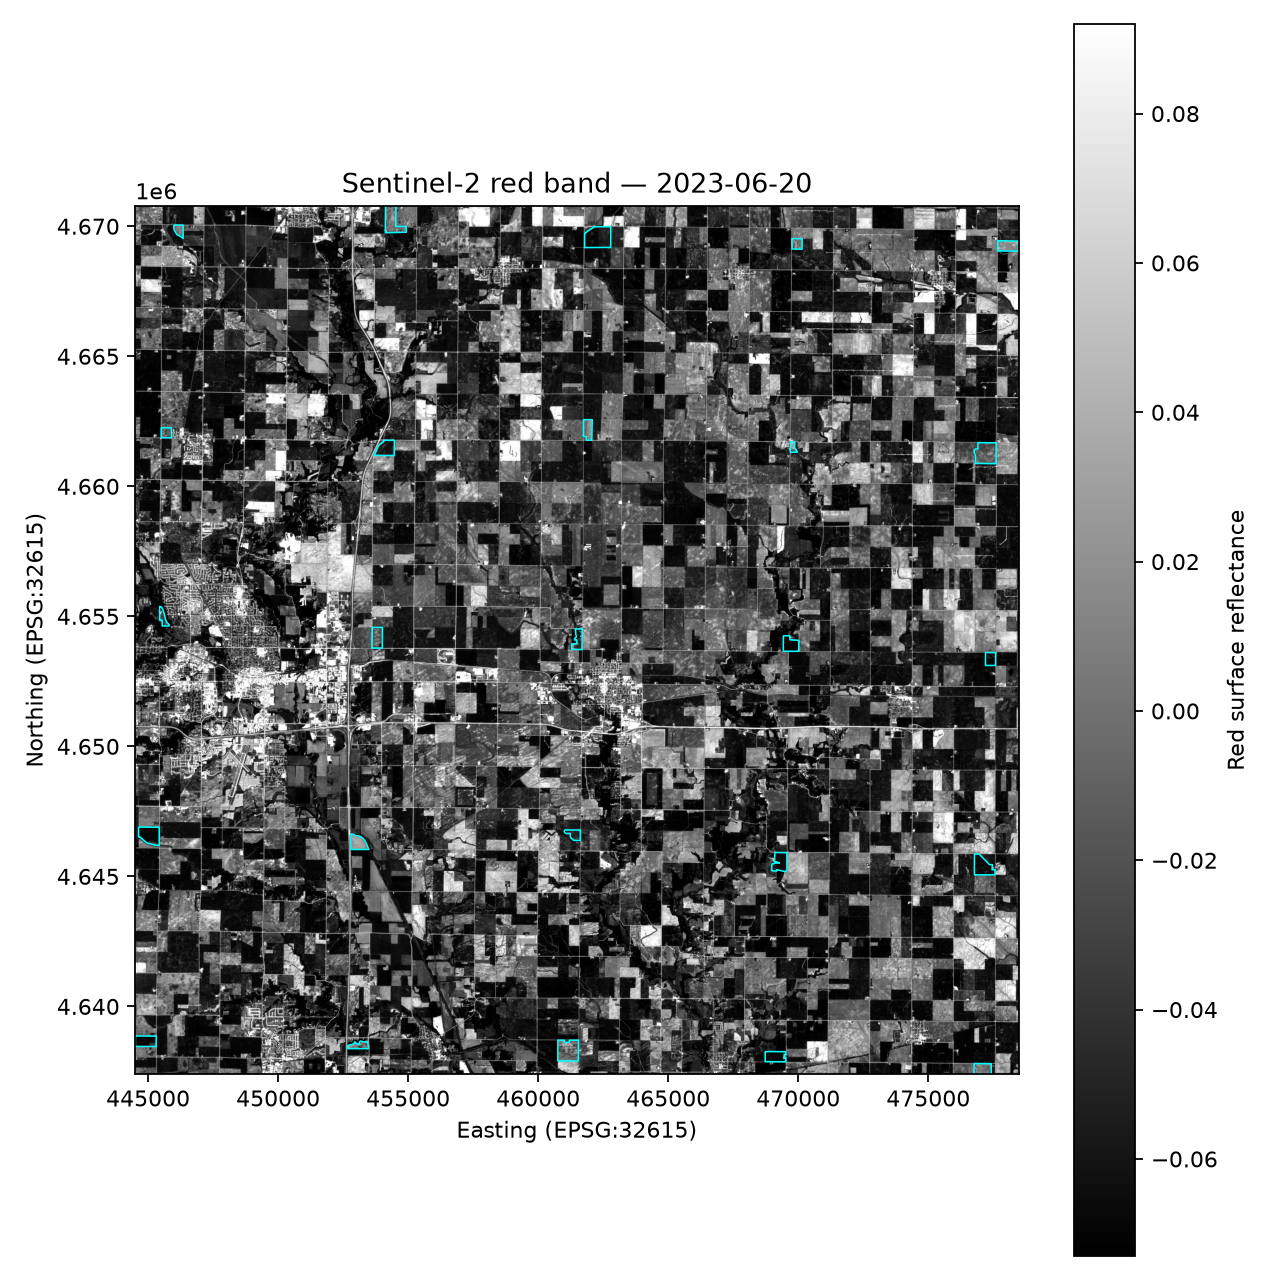

In [2]:
display(Image(filename=str(ROOT / "docs/assets/sentinel_red_band.png")))

## Cloud mask, reflectance, and NDVI

SCL classes 4, 5, 6, and 7 are retained; classes 0, 1, 2, 3, 8, 9, 10, and 11 are excluded. The 20 m SCL raster is reprojected to the red-band 10 m grid with nearest-neighbor resampling. Each reflectance band uses its own STAC scale and offset before `(NIR - red) / (NIR + red)` is calculated. Raw nodata, invalid SCL, outside-field pixels, non-finite values, and zero denominators are masked; finite NDVI is clipped to `[-1, 1]`.

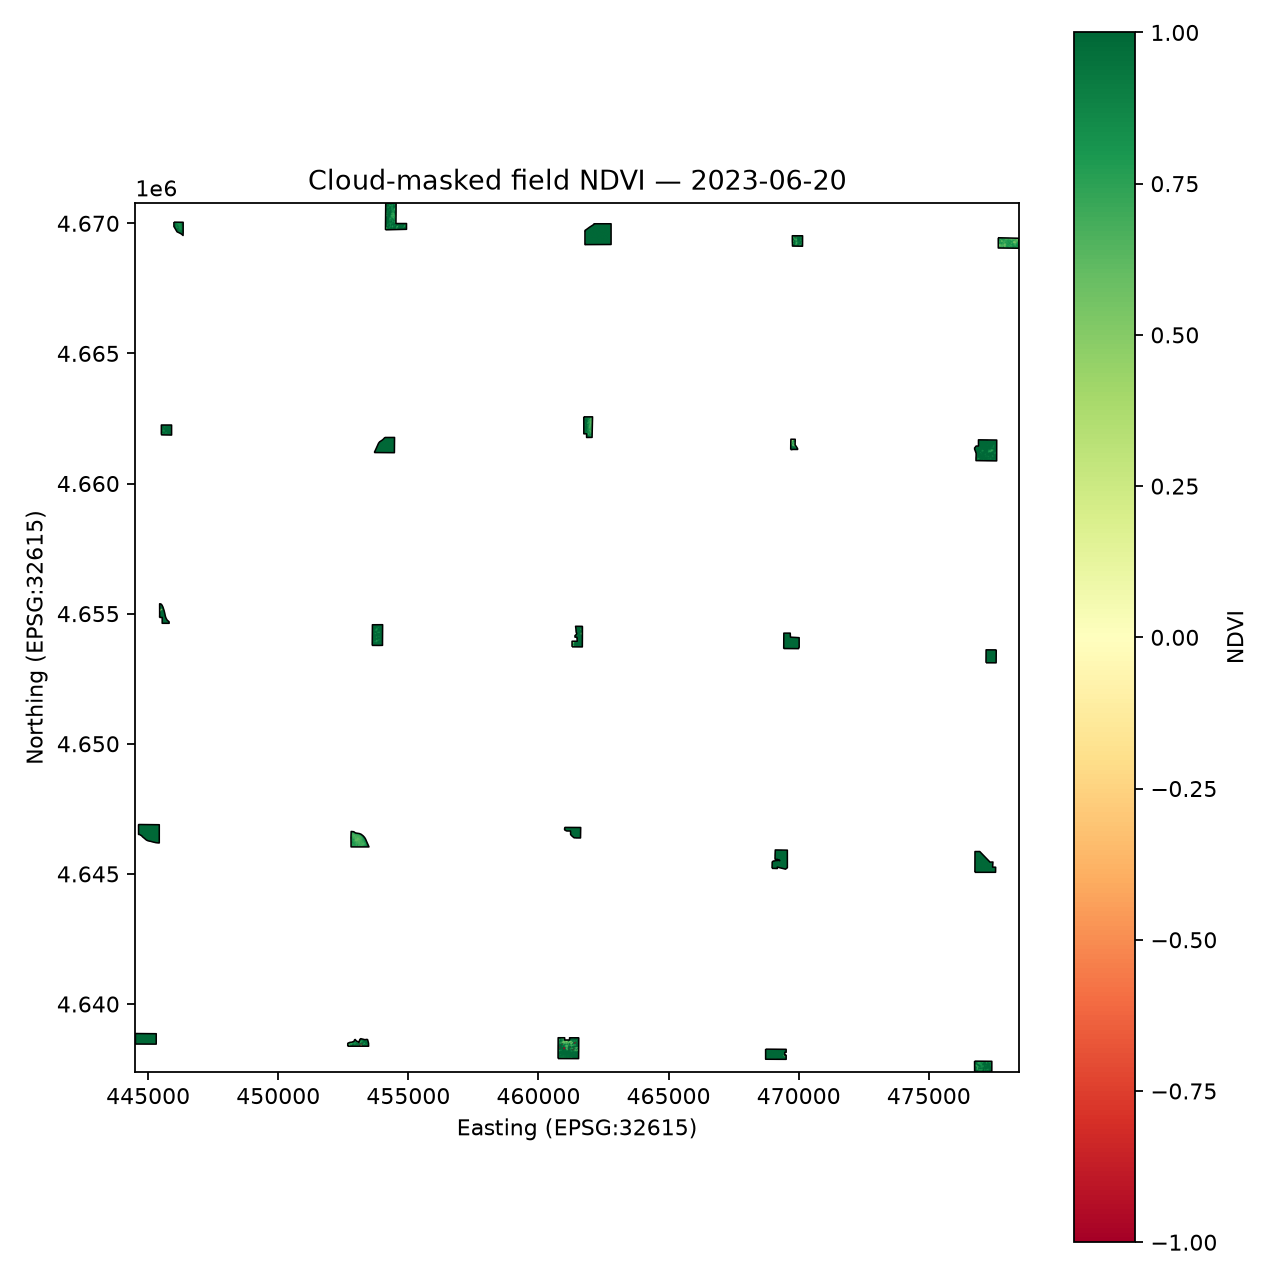

In [3]:
display(Image(filename=str(ROOT / "docs/assets/ndvi_map.png")))

## Field-level NDVI distribution

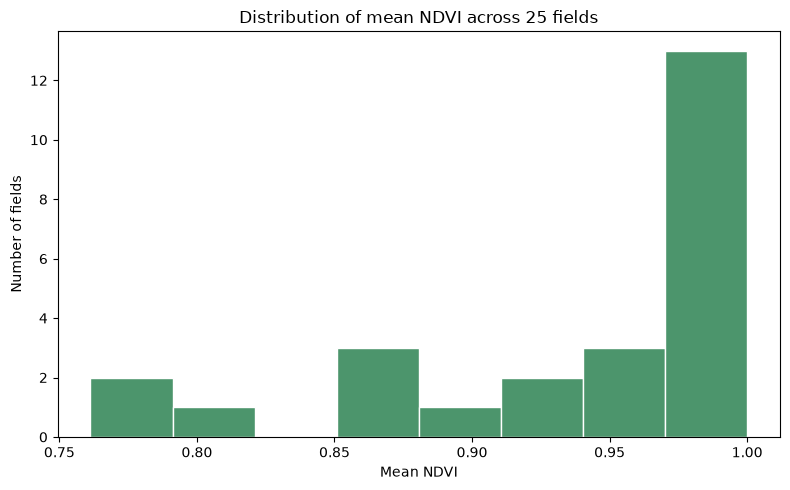

       mean_ndvi  median_ndvi  coverage_fraction
count    25.0000      25.0000               25.0
mean      0.9418       0.9649                1.0
std       0.0745       0.0745                0.0
min       0.7613       0.7412                1.0
25%       0.9054       0.9738                1.0
50%       0.9833       1.0000                1.0
75%       0.9997       1.0000                1.0
max       1.0000       1.0000                1.0


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(fields["mean_ndvi"], bins=8, color="#4C956C", edgecolor="white")
ax.set_title("Distribution of mean NDVI across 25 fields")
ax.set_xlabel("Mean NDVI")
ax.set_ylabel("Number of fields")
fig.tight_layout()
plt.show()

print(fields[["mean_ndvi", "median_ndvi", "coverage_fraction"]].describe().round(4).to_string())

## Interpretation and limitations

These values describe one clear-sky acquisition on June 20, 2023, not seasonal crop performance or yield. NDVI responds to canopy cover and growth stage, but also to soil background, atmospheric correction, and residual classification error. The field polygons are a 2019 USDA ACPF snapshot overlaid on 2023 imagery, so later boundary edits are not represented. SCL validity does not guarantee that every pixel is free from haze or sub-pixel cloud. These results are screening indicators, not operational farm recommendations.
After clipping, 3 of 25 field means and 17 of 25 field medians in the committed output are exactly 1.0. Those saturated fields hit the dense-canopy ceiling of the NDVI formula and should be read as ceiling values, not as precise rankings within that group.

**Attribution:** Contains modified Copernicus Sentinel data (2023), processed by ESA and accessed through the Element 84 Earth Search public-data catalog.